# Parte II - Deep Q-Learning (DQN)
LunarLander-v3 simula el aterrizaje de una nave espacial en una plataforma. El agente
controla tres propulsores y debe aterrizar suavemente entre las banderas que marcan la zona
de destino.


## Análisis del MDP

### Estados
La información relevante del entorno es toda referida a la nave, ya que la zona de aterrizaje está siempre ubicada en el mismo lugar.
El estado de la nave esta dado por un vector continuo con las siguientes 8 componentes:
- Sus coordenadas cartesianas (X,Y)
- Su velocidad inicial (Vx, Vy)
- Su ángulo respecto al eje horizontal (θ)
- Su velocidad angular (ω)
- 2 Valores booleanos representando la colisión de una de las dos patas con el suelo (L, R)

### Acciones 
La nave tiene 3 motores propulsores: inferior, izquierdo y derecho. Los cuales solo pueden encenderse a máxima potencia, uno a la vez (Acciones discretas). Las acciones posibles entonces son:

- [0] No hacer nada
- [1] Disparar propulsión izquierda
- [2] Disparar propulsión inferior
- [3] Disparar propulsión derecha

### Recompensa
Durante cada episodio, la recompensa es acumulativa y se calcula en cada paso/frame, siguiendo las siguientes reglas:

- Aumenta/disminuye según que tan cerca/lejos esté la nave de la plataforma de aterrizaje
- Aumenta/disminuye según que tan lento/rápido se esté moviendo la nave
- Disminuye según que tan inclinada esté la nave (ángulo no horizontal)
- Aumenta 10 puntos por cada pata que esté en contacto con el suelo
- Disminuye 0.03 puntos cada frame que un motor lateral esté encendido
- Disminuye 0.3 puntos cada frame que el motor inferior esté encendido

### Entorno
Es un entorno determinístico, cada estado (excepto el inicial) está completamente determinado por el estado anterior y la acción tomada.

El estado inicial esta dado por siempre la misma posición de la nave (centrada en el eje horizontal y a máxima altura) **pero** con una fuerza aleatoria aplicada a su centro de masa, por lo que cada episodio parte de un estado inicial diferente.


La tarea es episódica, donde cada episodio termina si:
- La Nave choca con la luna (Cuerpo de la nave colisiona)
- La Nave se sale de la pantalla 
- La Nave no se mueve ni colisiona (Por ejemplo si aterriza correctamente usando las patas)

In [37]:
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

import torch
import torch.nn as nn
import torch.optim as optim

import gymnasium as gym

In [38]:
# ── Reproducibilidad ───────────────────────
SEMILLA = 42
DEVICE = torch.device("cpu")

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    print(f"Semilla global fijada : {seed}")

set_seed(SEMILLA)

Semilla global fijada : 42


### DQN Base

In [ ]:
class RedDQN(nn.Module):
    def __init__(self, n_entradas, n_acciones):
        super().__init__()
        self.capa1 = nn.Linear(n_entradas, 128)
        self.capa2 = nn.Linear(128, 128)
        self.capa3 = nn.Linear(128, n_acciones)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.relu(self.capa1(x))
        x = self.relu(self.capa2(x))
        return self.capa3(x)

# ── Obtener dimensiones del entorno
_env_tmp = gym.make("LunarLander-v3")
_obs0, _ = _env_tmp.reset(seed=SEMILLA)
n_entradas = _env_tmp.observation_space.shape[0]
n_acciones = _env_tmp.action_space.n
_env_tmp.close()
print(f"n_entradas={n_entradas}, n_acciones={n_acciones}")


n_entradas=8, n_acciones=4


In [24]:
# ── Helpers: decaimiento de ε y política ε-greedy ────────────────────────────

def calcular_epsilon(episodio):
    '''Valor de ε en el episodio dado, con decaimiento exponencial.'''
    return max(epsilon_minimo,
               epsilon_inicial * np.exp(-tasa_decaimiento_epsilon * episodio))


def elegir_accion(red, estado, epsilon):
    '''
    Política ε-greedy: explora con prob. ε, explota con prob. (1-ε).

    Parámetros
    ----------
    red     : RedDQN -- red que estima Q(s, a)
    estado  : ndarray (4,) -- vector de estado actual
    epsilon : float -- probabilidad de exploración

    Devuelve
    --------
    accion : int (0 o 1)
    '''
    if np.random.rand() < epsilon:
        # Exploración: acción completamente aleatoria
        return np.random.randint(n_acciones)

    # Explotación: forward pass para obtener Q(s, a) de cada acción.
    # torch.no_grad() le dice a PyTorch que NO arme el grafo de autograd: acá
    # solo estamos eligiendo una acción (inferencia), no entrenando, así que
    # ahorramos memoria y cómputo al no rastrear gradientes.
    with torch.no_grad():
        # La red espera un batch. unsqueeze(0) agrega la dimensión de batch
        # al frente: (4,) → (1, 4), es decir, "un batch de un solo estado".
        tensor_estado = torch.tensor(estado, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        valores_q = red(tensor_estado)    # forma (1, 2) → un Q-value por acción
        # argmax() devuelve el índice del mayor Q (la mejor acción) como tensor;
        # .item() lo pasa a un int de Python para poder devolverlo.
        return int(valores_q.argmax().item())


# ── Verificación: evolución de ε (se imprime DESPUÉS de definir los hiperparámetros)
# Esta verificación se ejecuta una vez que epsilon_inicial, epsilon_minimo y
# tasa_decaimiento_epsilon estén definidos (celda siguiente).

In [40]:
# ── Hiperparámetros ───────────────────────────────────────────────────────────

tasa_aprendizaje = 1e-3
# Tasa de aprendizaje del optimizador Adam. 1e-3 es el valor por defecto
# de Adam y funciona bien en redes pequeñas. Valores más altos pueden causar
# divergencia; más bajos hacen el entrenamiento innecesariamente lento.

factor_descuento = 0.99
# γ: el agente valora recompensas futuras casi tanto como inmediatas.
# La señal de recompensa llega en cada paso (+1/paso, señal densa), así que
# γ alto permite al agente planificar secuencias largas de equilibrio.

epsilon_inicial          = 1.0
# Al inicio, exploración pura: el agente no sabe nada y conviene probar
# acciones al azar para llenar el buffer con experiencias variadas.

epsilon_minimo           = 0.01
# Mantenemos siempre una pequeña exploración residual para que el agente
# no quede atrapado en un mínimo local de la política aprendida.

tasa_decaimiento_epsilon = 0.01
# Controla la velocidad del decaimiento exponencial de ε.
# Con este valor, ε cae de 1.0 a ~0.01 en ~460 episodios, garantizando
# que el agente explote su política aprendida antes de los últimos episodios.

tamanio_batch = 64
# Número de transiciones que se muestrean del buffer en cada actualización.
# 64 es un buen compromiso entre estabilidad del gradiente y velocidad de cómputo.

capacidad_buffer = 50_000
# El buffer almacena las últimas 50 000 transiciones. Un buffer grande provee
# más diversidad en los mini-batches; uno pequeño solo contiene lo más reciente.

inicio_aprendizaje = 1_000
# El agente actúa aleatoriamente hasta acumular 1 000 transiciones.
# Esto asegura que el primer mini-batch tenga suficiente diversidad antes
# de hacer el primer paso de gradiente.

freq_sincronizacion_target = 5
# Hard update: cada 5 episodios se copian los pesos de la red de política
# a la red objetivo (θ⁻ ← θ). Con una frecuencia moderada la red objetivo
# rastrea el progreso reciente sin causar inestabilidad por targets muy cambiantes.

n_episodios_max = 400

umbral_resolucion = 475
# Criterio estándar de Gymnasium: reward promedio >= 475 en 100 episodios
# consecutivos. El reward máximo posible por episodio es 500.

print("Hiperparámetros configurados:")
print(f"  Tasa de aprendizaje (lr)         : {tasa_aprendizaje}")
print(f"  Factor de descuento (γ)          : {factor_descuento}")
print(f"  ε inicial / mínimo               : {epsilon_inicial} / {epsilon_minimo}")
print(f"  Tasa decaimiento ε               : {tasa_decaimiento_epsilon}")
print(f"  Tamaño de batch                  : {tamanio_batch}")
print(f"  Capacidad del buffer             : {capacidad_buffer:,}")
print(f"  Inicio del aprendizaje           : {inicio_aprendizaje:,} transiciones")
print(f"  Sincronización target network    : cada {freq_sincronizacion_target} episodios")
print(f"  Episodios máximos                : {n_episodios_max:,}")
print(f"  Umbral de resolución             : reward promedio >= {umbral_resolucion}")
print()
print("Evolución de ε durante el entrenamiento:")
for ep_check in [0, 50, 100, 150, 200, 250, 300, 350, 400]:
    print(f"  ε en episodio {ep_check:>4} : {calcular_epsilon(ep_check):.4f}")

Hiperparámetros configurados:
  Tasa de aprendizaje (lr)         : 0.001
  Factor de descuento (γ)          : 0.99
  ε inicial / mínimo               : 1.0 / 0.01
  Tasa decaimiento ε               : 0.01
  Tamaño de batch                  : 64
  Capacidad del buffer             : 50,000
  Inicio del aprendizaje           : 1,000 transiciones
  Sincronización target network    : cada 5 episodios
  Episodios máximos                : 400
  Umbral de resolución             : reward promedio >= 475

Evolución de ε durante el entrenamiento:
  ε en episodio    0 : 1.0000
  ε en episodio   50 : 0.6065
  ε en episodio  100 : 0.3679
  ε en episodio  150 : 0.2231
  ε en episodio  200 : 0.1353
  ε en episodio  250 : 0.0821
  ε en episodio  300 : 0.0498
  ε en episodio  350 : 0.0302
  ε en episodio  400 : 0.0183


In [ ]:
# ── Función reusable: animar episodio de un agente ───────────────────────────
def animate_agent_episode(agent, env_name='LunarLander-v3', seed=123, max_steps=1000,
                          interval=40, figsize=(6, 6), epsilon=0.0, display_now=True):
    """
    Ejecuta 1 episodio con `agent` y devuelve la animación HTML + métricas.
    Retorna: (html_anim, total_reward, n_frames)
    """
    env = gym.make(env_name, render_mode='rgb_array')
    obs, _ = env.reset(seed=seed)
    frames = []
    total_reward = 0.0

    for _ in range(max_steps):
        action = elegir_accion(agent, obs, epsilon=epsilon)
        obs, reward, terminated, truncated, _info = env.step(action)
        total_reward += float(reward)
        frames.append(env.render())
        if terminated or truncated:
            break

    env.close()

    fig = plt.figure(figsize=figsize)
    plt.axis('off')
    im = plt.imshow(frames[0])

    def _update(i):
        im.set_array(frames[i])
        return (im,)

    ani = FuncAnimation(fig, _update, frames=len(frames), interval=interval)
    html_anim = HTML(ani.to_jshtml())
    plt.close(fig)

    if display_now:
        display(html_anim)

    return html_anim, total_reward, len(frames)

In [27]:
def optimizar_paso_base(red_policy, estado, accion, recompensa, sig_estado, done, optimizador, gamma, device="cpu"):
    """
    Ejecuta un paso de optimización usando SOLO la transición actual.
    NO usa buffer de repetición ni red objetivo.
    """
    # 1. Convertir la transición individual a tensores y simular un batch de tamaño 1 (unsqueeze)
    estado_t = torch.FloatTensor(estado).unsqueeze(0).to(device)
    sig_estado_t = torch.FloatTensor(sig_estado).unsqueeze(0).to(device)
    accion_t = torch.LongTensor([accion]).view(-1, 1).to(device)
    recompensa_t = torch.FloatTensor([recompensa]).to(device)
    done_t = torch.FloatTensor([float(done)]).to(device)

    # 2. Calcular Q(s, a) actual usando la red de política
    q_valores = red_policy(estado_t)
    q_actual = q_valores.gather(1, accion_t)

    # 3. Calcular el Target Y_t usando la MISMA red de política (Sin Target Network)
    with torch.no_grad():
        q_sig_valores = red_policy(sig_estado_t)
        max_q_sig = q_sig_valores.max(1)[0].unsqueeze(1)
        # Si done es True, el target es solo la recompensa
        target = recompensa_t + gamma * max_q_sig * (1 - done_t)

    # 4. Calcular la pérdida (Huber loss) y retropropagar
    loss = nn.functional.smooth_l1_loss(q_actual, target)

    optimizador.zero_grad()
    loss.backward()
    
    # Gradient clipping para evitar que los gradientes exploten (muy común sin ER/TN)
    torch.nn.utils.clip_grad_value_(red_policy.parameters(), 100)
    
    optimizador.step()

    return loss.item()

In [28]:
# Hiperparámetros según las restricciones del TP (deben ser iguales para las 3 versiones)
n_episodios_max = 400 # Límite fijo requerido por el enunciado
factor_descuento = 0.99
DEVICE = torch.device("cpu") # O "cuda" si estás usando GPU

# Inicializar entorno, red y optimizador (asumiendo que ya definiste RedDQN y elegir_accion)
env = gym.make("LunarLander-v3")
red_policy = RedDQN(8, 4).to(DEVICE) 
optimizador = optim.Adam(red_policy.parameters(), lr=1e-3)

recompensas_por_episodio = []
losses_por_paso = [] # Te va a servir para graficar la pérdida y ver la inestabilidad

print("Iniciando entrenamiento DQN BASE (Sin ER, Sin TN) en LunarLander-v3...")

for ep in range(n_episodios_max):
    estado, _ = env.reset()
    done = False
    reward_acumulado = 0
    
    # Calcular epsilon actual (necesitás tu función calcular_epsilon)
    epsilon = calcular_epsilon(ep)
    
    while not done:
        # 1. Elegir acción (epsilon-greedy)
        accion = elegir_accion(red_policy, estado, epsilon)
        
        # 2. Ejecutar acción en el entorno
        sig_estado, recompensa, terminated, truncated, _ = env.step(accion)
        done = terminated or truncated
        
        # 3. Optimizar INMEDIATAMENTE (Acá radica la diferencia fundamental)
        loss = optimizar_paso_base(
            red_policy, estado, accion, recompensa, sig_estado, done, optimizador, factor_descuento, DEVICE
        )
        losses_por_paso.append(loss)
        
        # 4. Actualizar estado y reward
        estado = sig_estado
        reward_acumulado += recompensa
        
    recompensas_por_episodio.append(reward_acumulado)
    
    if (ep + 1) % 50 == 0:
        media_movil = np.mean(recompensas_por_episodio[-50:])
        print(f"Episodio {ep+1:3d} | Reward medio (50 ep): {media_movil:6.1f} | Epsilon: {epsilon:.3f}")

env.close()

Iniciando entrenamiento DQN BASE (Sin ER, Sin TN) en LunarLander-v3...
Episodio  50 | Reward medio (50 ep): -158.7 | Epsilon: 0.613
Episodio 100 | Reward medio (50 ep):  -82.7 | Epsilon: 0.372
Episodio 150 | Reward medio (50 ep):   -7.9 | Epsilon: 0.225
Episodio 200 | Reward medio (50 ep):    3.5 | Epsilon: 0.137
Episodio 250 | Reward medio (50 ep):   97.1 | Epsilon: 0.083
Episodio 300 | Reward medio (50 ep):  168.9 | Epsilon: 0.050
Episodio 350 | Reward medio (50 ep):  182.8 | Epsilon: 0.031
Episodio 400 | Reward medio (50 ep):  160.7 | Epsilon: 0.018


In [31]:
_, r_eval, n = animate_agent_episode(red_policy, seed=SEMILLA, display_now=True)

In [34]:
def graficar_entrenamiento(recompensas, losses, titulo_modelo, ventana=20):
    """
    Grafica el reward por episodio y el loss por paso de optimización.
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    # --- Gráfico 1: Reward por Episodio ---
    episodios = np.arange(1, len(recompensas) + 1)
    ax1.plot(episodios, recompensas, alpha=0.3, color="steelblue", label="Reward bruto")
    
    # Media móvil
    if len(recompensas) >= ventana:
        media_movil = np.convolve(recompensas, np.ones(ventana)/ventana, mode="valid")
        ax1.plot(np.arange(ventana, len(recompensas) + 1), media_movil, 
                 color="darkblue", linewidth=2, label=f"Media móvil (v={ventana})")
    
    # Líneas de referencia
    ax1.axhline(y=0, color="gray", linestyle="--", linewidth=1)
    ax1.axhline(y=200, color="green", linestyle="--", linewidth=1.5, label="Umbral 200")
    
    ax1.set_xlabel("Episodio")
    ax1.set_ylabel("Reward Acumulado")
    ax1.set_title(f"Evolución del Reward: {titulo_modelo}")
    ax1.legend(loc="upper left")
    ax1.grid(True, alpha=0.3)

    # --- Gráfico 2: Loss por Paso de Optimización ---
    pasos = np.arange(1, len(losses) + 1)
    ax2.plot(pasos, losses, color="crimson", alpha=0.8, linewidth=0.5)
    
    ax2.set_xlabel("Paso de Optimización")
    ax2.set_ylabel("Loss")
    ax2.set_title(f"Loss de Entrenamiento: {titulo_modelo}")
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

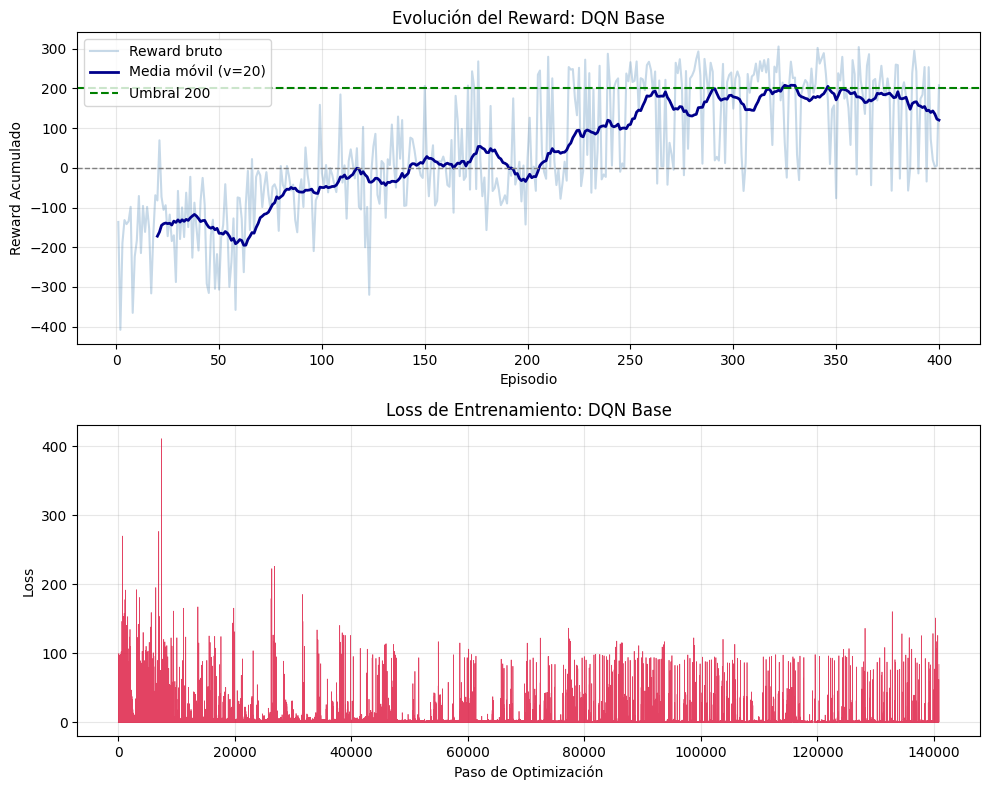

In [35]:
graficar_entrenamiento(recompensas_por_episodio, losses_por_paso, "DQN Base", ventana=20)